In [1]:
from finsler_embedding.experiment_run import *

/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
cfg = ExperimentConfig(
    N=5000,
    m=2,
    beta=0.5,
    K=400,
    n_neighbors=10,
    omega_type="random",
    function_type="mexican",
    device="cpu",
    export_path=None,
)

In [3]:
X = sample_uniform(cfg.N, bounds=(-2, 2, -2, 2))
# X = sample_grid(cfg.N, bounds=(-2, 2, -2, 2))
# Shuffle the data to avoid any ordering effects
X = X[torch.randperm(X.shape[0])]
cfg.N = X.shape[0]  # Update N in case of grid sampling
X = X.to(torch.float).to(cfg.device)
bounds = get_bounds(X, margin=0.01)

base_cometric = IdentityCoMetric().to(cfg.device)
omega_true = get_omega(cfg.omega_type, base_cometric).to(cfg.device)
randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=cfg.beta,
)


In [4]:
b_true = randers_metric.omega(X) * randers_metric.beta
v_true = b_to_v(b_true, base_cometric.cometric_tensor(X)).detach()
v_true_norm = v_true.norm(dim=1)

In [5]:
edges = get_knn_graph(X, n_neighbors=10, device=cfg.device)
LOGGER.info(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X, edges, randers_metric,use_approx=True)


[2026-09-11 14:27:52] - INFO - Found 57268 edges in the KNN graph.


Computing Randers distances: 100%|██████████| 573/573 [00:01<00:00, 486.16it/s]


In [6]:
c_km, L_theta_a = prepare_operators(cfg, X, edges, dst_edges)

[2026-09-11 14:27:54] - INFO - Computing epsilon, W, mu_0, mu_1, and operators L_theta_s and L_theta_a...


[2026-09-11 14:27:54] - INFO - Lf_values_constant should be zero
[2026-09-11 14:27:54] - INFO - Lf_values_constant: mean = -1.88e-09, std = 2.20e-06, min = -1.14e-05, max = 1.14e-05
{'mean': -1.8765058396041923e-09, 'std': 2.2024623831384815e-06, 'min': -1.1444091796875e-05, 'max': 1.1444091796875e-05, 'quantile_5': -3.814697265625e-06, 'quantile_25': -9.5367431640625e-07, 'median': 0.0, 'quantile_75': 9.5367431640625e-07, 'quantile_95': 3.814697265625e-06}


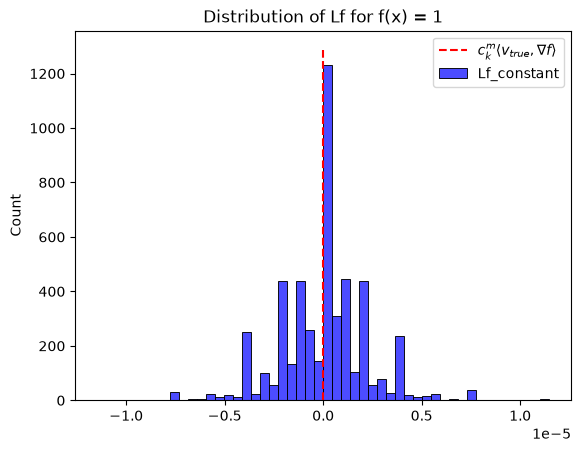

In [7]:
res_LF_value_constant, Lf_values_constant = check_constant_function(cfg, X, L_theta_a)
print(res_LF_value_constant)
sns.histplot(Lf_values_constant.detach().cpu().numpy().flatten(), bins=50,label="Lf_constant", color="blue", alpha=0.7)
plt.vlines(x=0, ymin=0, ymax=plt.gca().get_ylim()[1], colors="r", linestyles="dashed", label=r"$c_k^m\langle v_{true}, \nabla f \rangle$")
plt.title(f"Distribution of Lf for f(x) = 1")
plt.legend()
plt.show()

{'mean': 0.10508206486701965, 'std': 1.072961449623108, 'min': -4.181436538696289, 'max': 4.132785797119141, 'quantile_5': -1.6690208911895752, 'quantile_25': -0.6084015965461731, 'median': 0.14895451068878174, 'quantile_75': 0.8272949457168579, 'quantile_95': 1.8475672006607056}


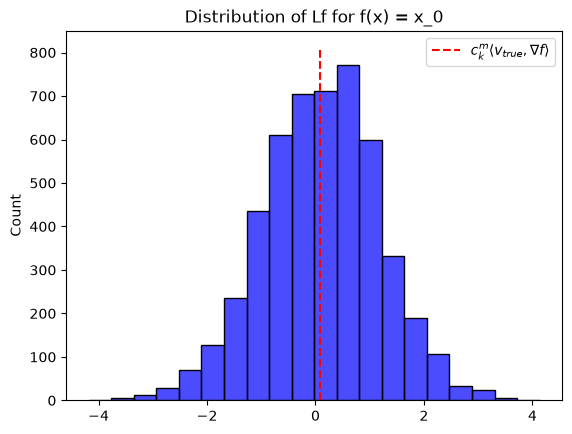

In [8]:
# Test of f(x) = x_coord
f_values_linear, Lf_values_linear, f_grad_values_linear = prepare_test_functions(
        cfg.K, "coordinates", X, L_theta_a
    )
true_rhs_linear = c_km * torch.einsum('n d, k n d -> k n', v_true, f_grad_values_linear)  # (1, N)

print(qqt_summary_statistics(Lf_values_linear.flatten()))
sns.histplot(Lf_values_linear.flatten().cpu().detach().numpy(), bins=20, color="blue", alpha=0.7)
# sns.histplot(true_rhs_linear.detach().cpu().numpy().flatten(), bins=50, label="true_rhs")
plt.title(f"Distribution of Lf for f(x) = x_0")
plt.vlines(x=true_rhs_linear.mean(), ymin=0, ymax=plt.gca().get_ylim()[1], colors="r", linestyles="dashed", label=r"$c_k^m\langle v_{true}, \nabla f \rangle$")
# plt.xscale("symlog")
plt.legend()
plt.show()

[2026-09-11 14:27:56] - INFO - Delta_rhs_norm = $lVert Lf_k(x_i) - c_km <v(x_i), nabla f_k(x_i)>rVert$
[2026-09-11 14:27:56] - INFO - Delta_rhs_norm: mean = 1.69e+02, std = 1.10e+02, min = 4.67e+01, max = 5.62e+02
[2026-09-11 14:27:56] - INFO - Ratio_rhs_mean should be 1
[2026-09-11 14:27:56] - INFO - Ratio_rhs_mean: mean = 6.71e-01, std = 7.96e+00, min = -2.91e+01, max = 1.50e+02


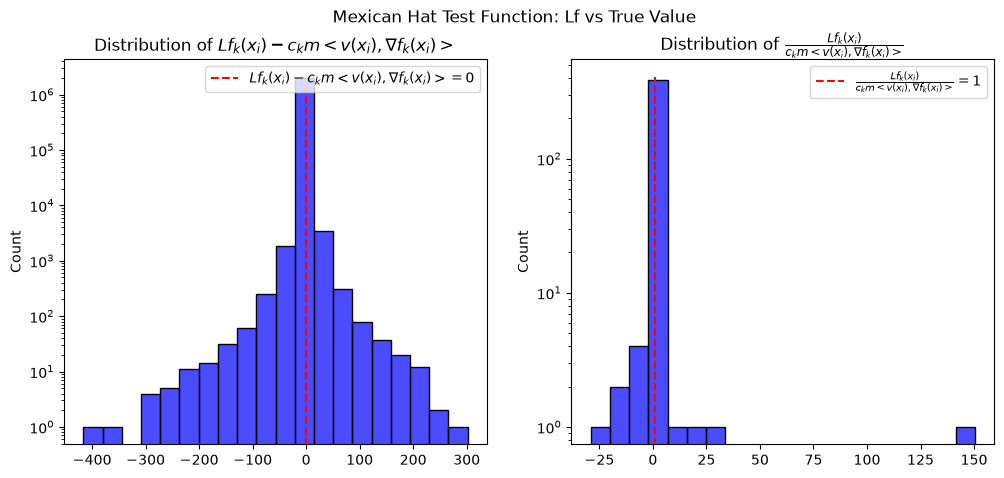

In [9]:
f_values_mexican, Lf_values_mexican, f_grad_values_mexican = prepare_test_functions(
        cfg.K, "mexican", X, L_theta_a
    )
true_rhs_mexican = c_km * torch.einsum('n d, k n d -> k n', v_true, f_grad_values_mexican)  # (1, N)
res_delta_rhs_norm_mexican, delta_rhs_mexican = check_true_value_delta(true_rhs_mexican, Lf_values_mexican)
res_ratio_rhs_mean_mexican, ratio_rhs_mean_mexican = check_true_value_ratio(true_rhs_mexican, Lf_values_mexican)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(delta_rhs_mexican.flatten().cpu().detach().numpy(), bins=20, color="blue", alpha=0.7,ax=axes[0])
axes[0].set_title(r"Distribution of $Lf_k(x_i) - c_km <v(x_i), \nabla f_k(x_i)>$")
axes[0].vlines(x=0, ymin=0, ymax=axes[0].get_ylim()[1], colors="r", linestyles="dashed", label=r"$Lf_k(x_i) - c_km <v(x_i), \nabla f_k(x_i)> = 0$")
sns.histplot(
        ratio_rhs_mean_mexican.flatten().cpu().detach().numpy(), bins=20, color="blue", alpha=0.7, ax=axes[1]
    )
axes[1].vlines(x=1, ymin=0, ymax=axes[1].get_ylim()[1], colors="r", linestyles="dashed", label=r"$\frac{Lf_k(x_i)}{c_km <v(x_i), \nabla f_k(x_i)>} = 1$")
axes[1].set_title(r"Distribution of $\frac{Lf_k(x_i)}{c_km <v(x_i), \nabla f_k(x_i)>}$")
for ax in axes:
    ax.legend()
    ax.set_yscale("log")

fig.suptitle("Mexican Hat Test Function: Lf vs True Value")
plt.show()

[2026-09-11 14:27:58] - INFO - Delta_rhs_norm = $lVert Lf_k(x_i) - c_km <v(x_i), nabla f_k(x_i)>rVert$
[2026-09-11 14:27:58] - INFO - Delta_rhs_norm: mean = 2.16e+01, std = 3.63e+00, min = 1.05e+01, max = 3.59e+01
[2026-09-11 14:27:58] - INFO - Ratio_rhs_mean should be 1
[2026-09-11 14:27:58] - INFO - Ratio_rhs_mean: mean = 2.42e-01, std = 2.05e+00, min = -2.60e+01, max = 1.58e+01


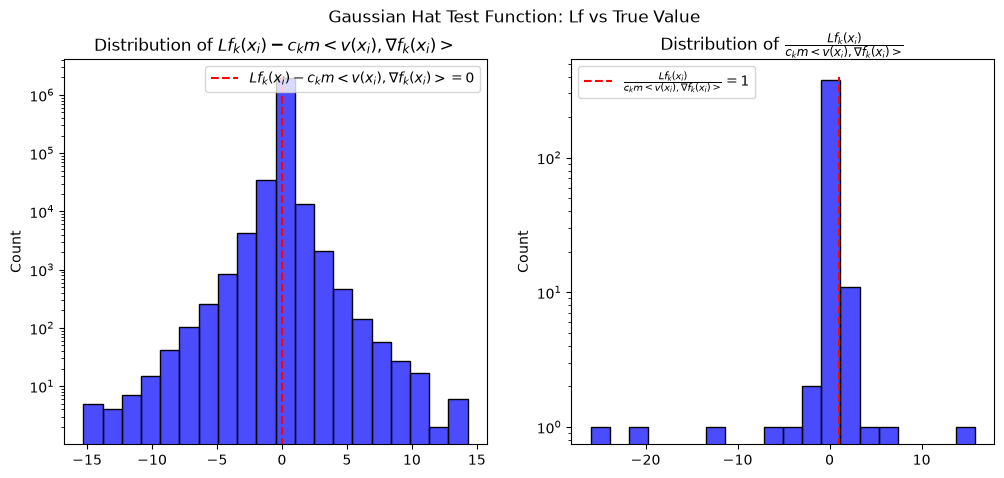

In [10]:
f_values_gaussian, Lf_values_gaussian, f_grad_values_gaussian = prepare_test_functions(
        cfg.K, "gaussian", X, L_theta_a
    )
true_rhs_gaussian = c_km * torch.einsum('n d, k n d -> k n', v_true, f_grad_values_gaussian)  # (1, N)
res_delta_rhs_norm_gaussian, delta_rhs_gaussian = check_true_value_delta(true_rhs_gaussian, Lf_values_gaussian)
res_ratio_rhs_mean_gaussian, ratio_rhs_mean_gaussian = check_true_value_ratio(true_rhs_gaussian, Lf_values_gaussian)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(delta_rhs_gaussian.flatten().cpu().detach().numpy(), bins=20, color="blue", alpha=0.7,ax=axes[0])
axes[0].set_title(r"Distribution of $Lf_k(x_i) - c_km <v(x_i), \nabla f_k(x_i)>$")
axes[0].vlines(x=0, ymin=0, ymax=axes[0].get_ylim()[1], colors="r", linestyles="dashed", label=r"$Lf_k(x_i) - c_km <v(x_i), \nabla f_k(x_i)> = 0$")
sns.histplot(
        ratio_rhs_mean_gaussian.flatten().cpu().detach().numpy(), bins=20, color="blue", alpha=0.7, ax=axes[1]
    )
axes[1].vlines(x=1, ymin=0, ymax=axes[1].get_ylim()[1], colors="r", linestyles="dashed", label=r"$\frac{Lf_k(x_i)}{c_km <v(x_i), \nabla f_k(x_i)>} = 1$")
axes[1].set_title(r"Distribution of $\frac{Lf_k(x_i)}{c_km <v(x_i), \nabla f_k(x_i)>}$")
for ax in axes:
    ax.legend()
    ax.set_yscale("log")

fig.suptitle("Gaussian Hat Test Function: Lf vs True Value")
plt.show()

[2026-09-11 14:28:00] - INFO - Delta_rhs_norm = $lVert Lf_k(x_i) - c_km <v(x_i), nabla f_k(x_i)>rVert$
[2026-09-11 14:28:00] - INFO - Delta_rhs_norm: mean = 9.27e+01, std = 9.94e+01, min = 1.17e+01, max = 4.87e+02
[2026-09-11 14:28:00] - INFO - Ratio_rhs_mean should be 1
[2026-09-11 14:28:00] - INFO - Ratio_rhs_mean: mean = 2.88e-01, std = 1.33e+00, min = -2.26e+01, max = 3.93e+00


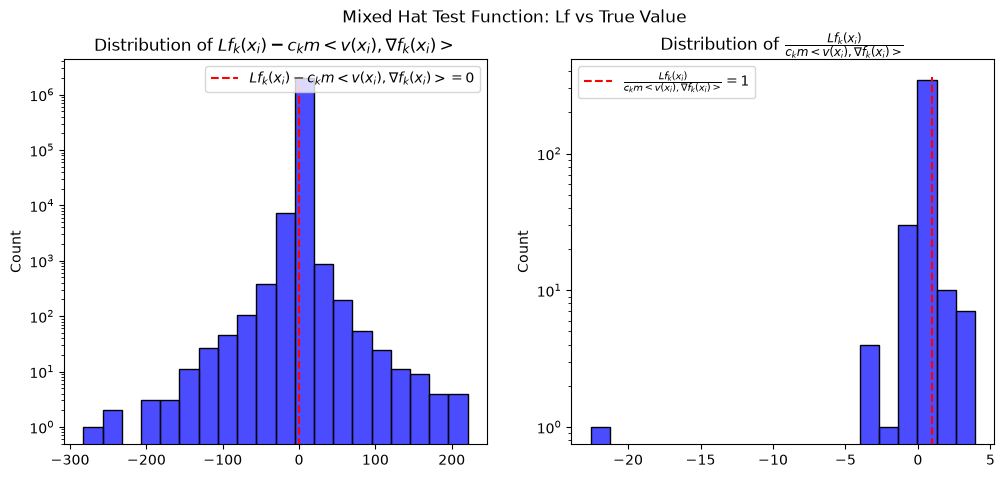

In [11]:
f_values_mixed, Lf_values_mixed, f_grad_values_mixed = prepare_test_functions(
        cfg.K, "mexican_and_gaussian", X, L_theta_a
    )
true_rhs_mixed = c_km * torch.einsum('n d, k n d -> k n', v_true, f_grad_values_mixed)  # (1, N)
res_delta_rhs_norm_mixed, delta_rhs_mixed = check_true_value_delta(true_rhs_mixed, Lf_values_mixed)
res_ratio_rhs_mean_mixed, ratio_rhs_mean_mixed = check_true_value_ratio(true_rhs_mixed, Lf_values_mixed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(delta_rhs_mixed.flatten().cpu().detach().numpy(), bins=20, color="blue", alpha=0.7,ax=axes[0])
axes[0].set_title(r"Distribution of $Lf_k(x_i) - c_km <v(x_i), \nabla f_k(x_i)>$")
axes[0].vlines(x=0, ymin=0, ymax=axes[0].get_ylim()[1], colors="r", linestyles="dashed", label=r"$Lf_k(x_i) - c_km <v(x_i), \nabla f_k(x_i)> = 0$")
sns.histplot(
        ratio_rhs_mean_mixed.flatten().cpu().detach().numpy(), bins=20, color="blue", alpha=0.7, ax=axes[1]
    )
axes[1].vlines(x=1, ymin=0, ymax=axes[1].get_ylim()[1], colors="r", linestyles="dashed", label=r"$\frac{Lf_k(x_i)}{c_km <v(x_i), \nabla f_k(x_i)>} = 1$")
axes[1].set_title(r"Distribution of $\frac{Lf_k(x_i)}{c_km <v(x_i), \nabla f_k(x_i)>}$")
for ax in axes:
    ax.legend()
    ax.set_yscale("log")

fig.suptitle("Mixed Hat Test Function: Lf vs True Value")
plt.show()

In [12]:
f_values, Lf_values, f_grad_values = prepare_test_functions(
        cfg.K, "mexican", X, L_theta_a
    )

[2026-09-11 14:28:02] - INFO - Training vector field models...


Loss: 7.3663e+00: 100%|██████████| 1000/1000 [00:02<00:00, 415.43it/s]


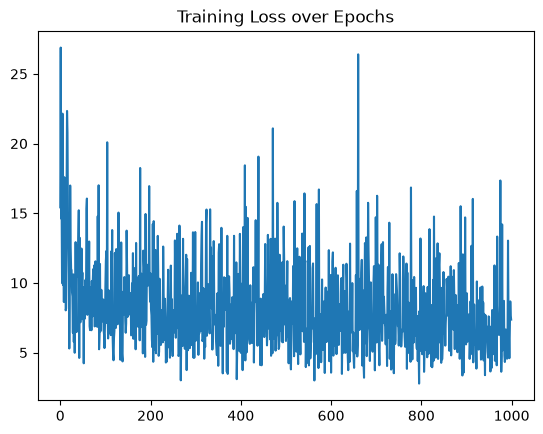

Relative Error (%) Statistics on the prediction of the operator:


{'mean': 140.75990295410156,
 'std': 35045.671875,
 'min': 0.0,
 'max': 48553976.0,
 'quantile_5': 0.0,
 'quantile_25': 0.0,
 'median': 7.106321334838867,
 'quantile_75': 53.77513885498047,
 'quantile_95': 202.05380249023438}

In [13]:
LOGGER.info("Training vector field models...")
v_model, omega_model, loss_list = train_vector_field_models(
    cfg, X, base_cometric, c_km, f_values, Lf_values, f_grad_values
)
v_hat_deep = v_model(X).detach()
b_hat_deep = omega_model(X).detach()
plt.plot(loss_list)
plt.title("Training Loss over Epochs")
plt.show()

# Compute relative error:
rhs = c_km * torch.einsum('n d, k n d -> k n', v_hat_deep, f_grad_values)  # (1, N)
relative_error = torch.where(torch.abs(Lf_values) > 1e-8, torch.abs(Lf_values - rhs) / torch.abs(Lf_values) * 100, torch.zeros_like(Lf_values))
print(f"Relative Error (%) Statistics on the prediction of the operator:")
qqt_summary_statistics(relative_error.flatten())

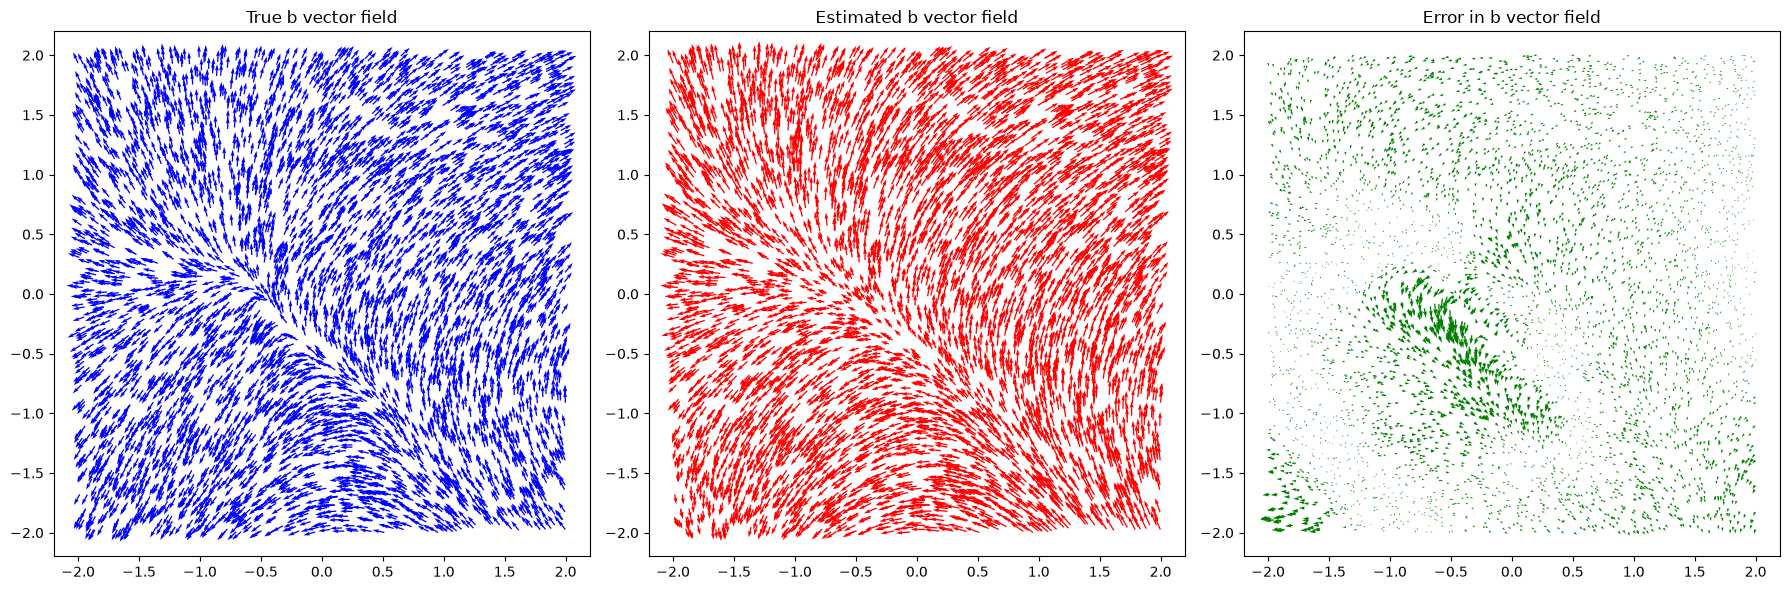

In [14]:
fig, axes = plot_side_by_side(X,b_true, b_hat_deep)

[2026-09-11 14:28:06] - INFO - Cosine similarity between true b and estimated b (Deep Model) should be 1
[2026-09-11 14:28:06] - INFO - Cosine similarity: mean = 9.78e-01, std = 6.26e-02, min = 1.13e-01, max = 1.00e+00
{'mean': 0.977611243724823, 'std': 0.06256423890590668, 'min': 0.11347958445549011, 'max': 1.0, 'quantile_5': 0.900624692440033, 'quantile_25': 0.9840089082717896, 'median': 0.9953078031539917, 'quantile_75': 0.9991469979286194, 'quantile_95': 0.999953031539917}


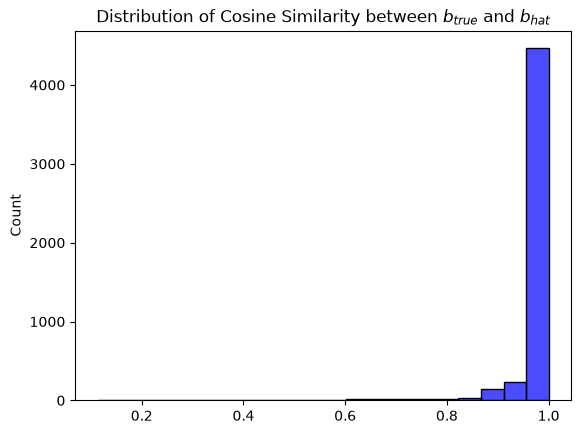

In [15]:
res_cosine_similarity_deep, cosine_similarity_deep = check_cosim_estimate(
        b_hat_deep, b_true
    )
print(qqt_summary_statistics(cosine_similarity_deep.flatten()))
sns.histplot(cosine_similarity_deep.flatten().cpu().detach().numpy(), bins=20, color="blue", alpha=0.7)
plt.title(r"Distribution of Cosine Similarity between $b_{true}$ and $b_{hat}$")
plt.vlines(x=1, ymin=0, ymax=axes[0].get_ylim()[1], colors="r", linestyles="dashed", label=r"$\cos(b_{true}, b_{hat}) = 1$")
plt.show()